In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [15]:
exp_2_data = pd.read_csv("data/dataset-12_2.csv")

In [16]:
exp_2_data.head()

,Time (s),Signal strength,Ax (m/s²),Ay (m/s²),Az (m/s²),Bx (µT),By (µT),Bz (µT),ωx (rad/s),ωy (rad/s),ωz (rad/s),Voltage (mV)
0,0.01,66,-0.225539,-0.002763,9.790105,-12.888433,-4.408291,63.739647,-0.054994,5.090871,-0.157546,-0.003140
1,0.02,66,-0.206455,-0.007571,9.776066,-13.359904,-3.731894,63.970856,-0.052742,5.053720,-0.150791,-0.003140
2,0.03,66,-0.220800,-0.007506,9.818894,-13.882917,-2.817244,64.886314,-0.054690,4.840719,-0.129756,-0.003663
3,0.04,66,-0.220800,-0.003173,9.800350,-14.313116,-1.893381,65.808838,-0.053969,4.571364,-0.110478,-0.003140
4,0.05,66,-0.220800,-0.026568,9.829031,-14.716823,-1.064858,65.821922,-0.051819,4.145122,-0.085812,-0.003663


In [ ]:

#boolean mask for the time range 19.2 < t < 22.5
mask = (exp_2_data['Time (s)'] > 19.2) & (exp_2_data['Time (s)'] < 22.5)

time = exp_2_data.loc[mask, 'Time (s)'].to_numpy()
B_z = exp_2_data.loc[mask, 'Bz (µT)'].to_numpy()
high_gain = exp_2_data.loc[mask, 'Voltage (mV)'].to_numpy()



<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/var/folders/gw/vj8kn7_14xl38ys22_8rvd8m0000gn/T/ipykernel_35231/1645837205.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Magnetic Field $B_z$ ($\mu$T)')


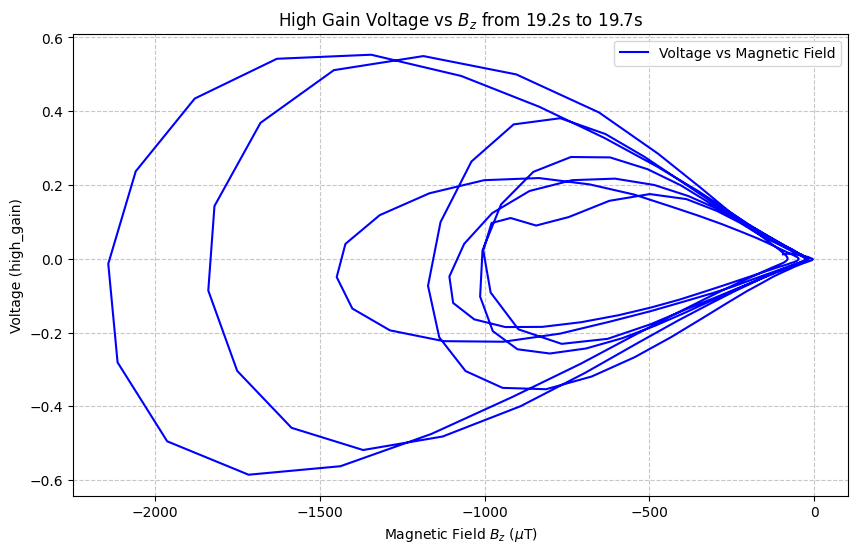

In [71]:
plt.figure(figsize=(10, 6))
plt.plot(B_z, high_gain, color='blue', label='Voltage vs Magnetic Field')

# Labeling the axes and title
plt.xlabel('Magnetic Field $B_z$ ($\mu$T)')
plt.ylabel('Voltage (high_gain)')
plt.title('High Gain Voltage vs $B_z$ from 19.2s to 19.7s')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Save and show
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/gw/vj8kn7_14xl38ys22_8rvd8m0000gn/T/ipykernel_35231/2313336314.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Magnetic Field change over Time $dB_z/dt$ ($\mu$T/s)')


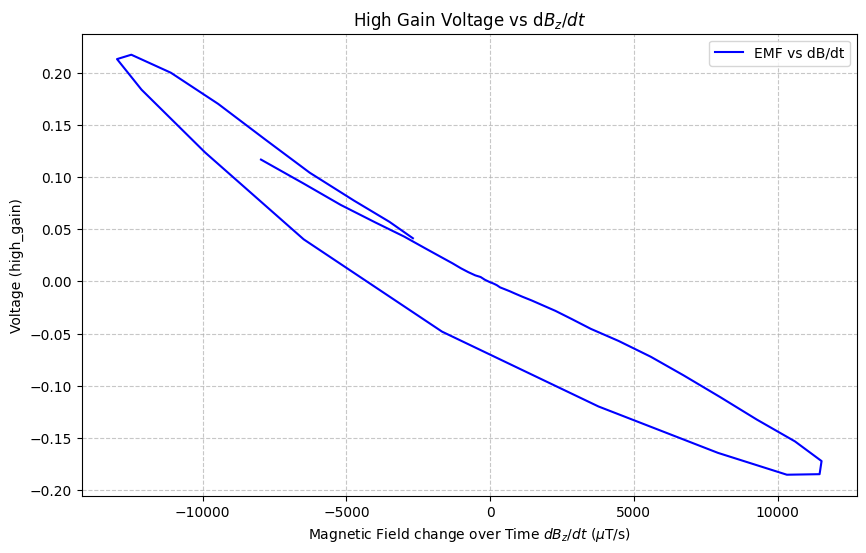

In [ ]:
dbz_dt = np.gradient(B_z, time)



plt.figure(figsize=(10, 6))
plt.plot(dbz_dt[100:150], high_gain[100:150], color='blue', label='EMF vs dB/dt')

# Labeling the axes and title
plt.xlabel('Magnetic Field change over Time $dB_z/dt$ ($\mu$T/s)')
plt.ylabel('Voltage (high_gain)')
plt.title('High Gain Voltage vs d$B_z/dt$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Save and show
plt.show()

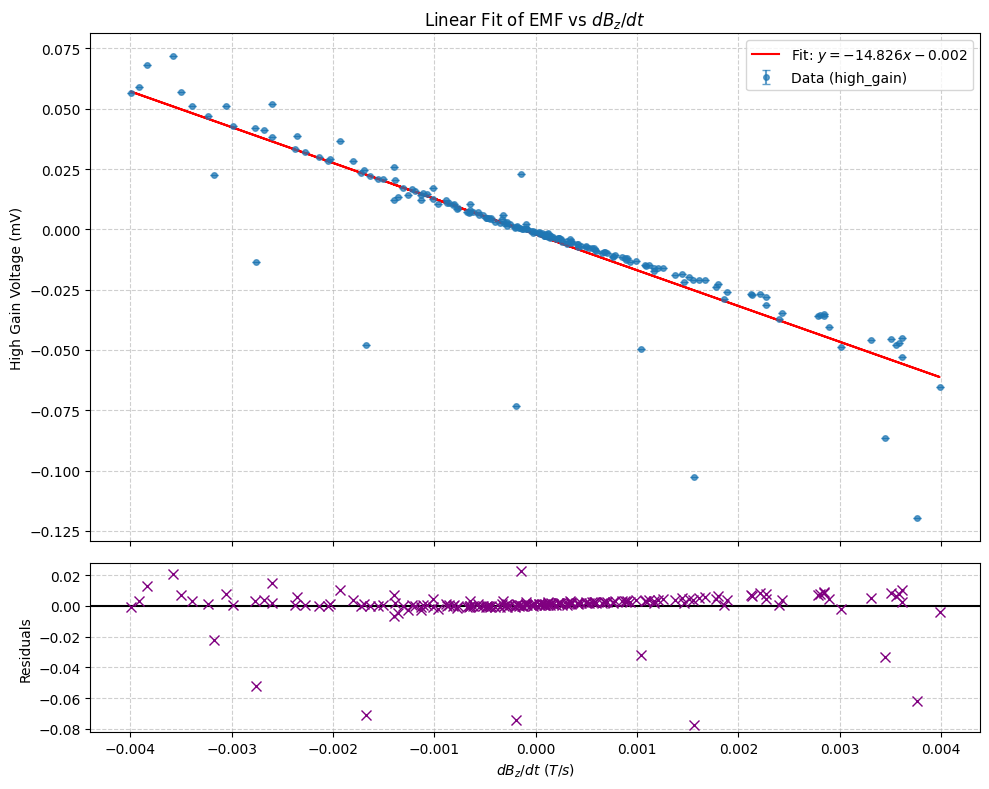

In [ ]:

def emf(dbdt, m, c):
    return m * dbdt + c

mask = [abs(i) < 4000 for i in dbz_dt]
x_data = dbz_dt[mask] / 10**6
y_data = high_gain[mask]

popt, pcov = curve_fit(emf, x_data, y_data)

m = popt[0]
c = popt[1]

perr = np.sqrt(np.diag(pcov))
m_err = perr[0]
c_err = perr[1]


y_fit = emf(x_data, m, c)
residuals = y_data - y_fit

# 5. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})


y_err = 0.000001

ax1.errorbar(x_data, y_data, yerr=y_err, fmt='o', markersize=4, 
             capsize=3, label='Data (high_gain)', alpha=0.7)
ax1.plot(x_data, y_fit, color='red', label=f'Fit: $y = {m:.3f}x {c:.3f}$')
ax1.set_ylabel('High Gain Voltage (mV)')
ax1.set_title('Linear Fit of EMF vs $dB_z/dt$')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Residual Plot ---
ax2.errorbar(x_data, residuals, yerr=y_err, fmt='x', color='purple', markersize=7)
ax2.axhline(0, color='black', linestyle='-')
ax2.set_ylabel('Residuals')
ax2.set_xlabel('$dB_z/dt$ ($T/s$)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [77]:
expected_m = np.pi * ((0.024/2)**2) * (23)
m_SI = m/1000.0

d = 0.024
alpha_d = 0.001
N = 23
alpha_N = 1

# m = pi * (d/2)^2 * N = (pi/4) * d^2 * N
m = np.pi * ((d/2)**2) * N

# dm/dd = (pi/2) * d * N
dm_dd = (np.pi / 2) * d * N

# dm/dN = (pi/4) * d^2
dm_dN = (np.pi / 4) * (d**2)

# alpha_m = sqrt( (dm/dd * alpha_d)^2 + (dm/dN * alpha_N)^2 )
alpha_m = np.sqrt((dm_dd * alpha_d)**2 + (dm_dN * alpha_N)**2)

In [78]:
#agreement test
def agreement_test(x_fit, x_accepted, alpha_fit, alpha_accepted, printResults):
    diff = abs(x_accepted - x_fit)
    combined_uncertainty = 2 * (alpha_fit + alpha_accepted)
    if printResults:

        print(f"Accepted value: {x_accepted:.3e} ± {alpha_accepted:.3e}")
        print(f"Calculated value: {x_fit:.3e} ± {alpha_fit:.3e}")

        print(f"\n--- Agreement Test ---")
        print(f"Difference (|x_fit - x_accepted|): {diff:.3f}")
        print(f"Combined Uncertainty: {combined_uncertainty:.3f}")
        if diff <= combined_uncertainty:
            print("Passed agreement test.")
        else:
            print("Failed agreement test.")
    return diff <= combined_uncertainty

In [80]:
agreement_test(abs(m_SI), expected_m, m_err, alpha_m, True)

Accepted value: 1.040e-02 ± 9.780e-04
Calculated value: 1.483e-02 ± 5.631e-01

--- Agreement Test ---
Difference (|x_fit - x_accepted|): 0.004
Combined Uncertainty: 1.128
Passed agreement test.


np.True_

In [81]:
exp_1_data = pd.read_csv("data/dataset-12_1.csv")

In [93]:
exp_1_data.tail()


,Time (s),Signal strength,Ax (m/s²),Ay (m/s²),Az (m/s²),Bx (µT),By (µT),Bz (µT),ωx (rad/s),ωy (rad/s),ωz (rad/s),Voltage (mV)
6063,60.639999,53,2.596951,-9.880187,-1.127933,-4.681036,34.664028,1.031133,-0.124548,13.714459,-0.112934,-0.003663
6064,60.650002,52,2.587478,-9.885039,-1.127046,-5.313005,34.716248,1.024112,-0.114531,13.687849,-0.123945,-0.003140
6065,60.660000,52,2.573025,-9.889892,-1.136574,-5.953846,34.539413,0.553883,-0.101015,13.663611,-0.129023,-0.003140
6066,60.669998,50,2.563265,-9.880386,-1.131920,-6.653606,34.232033,0.363896,-0.093452,13.631843,-0.125594,-0.002616
6067,60.680000,48,2.553571,-9.880298,-1.117451,-7.412287,34.232033,0.289485,-0.074626,13.600073,-0.124417,-0.003140


In [98]:


mask = (exp_1_data['Time (s)'] > 40) & (exp_1_data['Time (s)'] < 60)

time = exp_1_data.loc[mask, 'Time (s)'].to_numpy()
w_y = exp_1_data.loc[mask, 'ωy (rad/s)'].to_numpy()
high_gain = exp_1_data.loc[mask, 'Voltage (mV)'].to_numpy()


In [102]:

# bin size (how many data points to group together)
bin_size = 125

w_y_bins = []
v_max_bins = []
v_min_bins = []

for i in range(0, len(w_y), bin_size):
    # Get the slice of data
    w_slice = w_y[i:i+bin_size]
    v_slice = high_gain[i:i+bin_size]
    
    if len(w_slice) > 0:
        # Use the average omega for the x-axis of the bin
        w_y_bins.append(np.mean(w_slice))
        # Get the peaks (envelope)
        v_max_bins.append(np.max(v_slice))
        v_min_bins.append(np.min(v_slice))


In [103]:
# 2. Linear Regression for the envelopes
def model(x, m, c):
    return m * x + c

popt_top, _ = curve_fit(model, w_y_bins, v_max_bins)
popt_bot, _ = curve_fit(model, w_y_bins, v_min_bins)

# The slope of interest is the average magnitude of these two slopes
m_avg = (abs(popt_top[0]) + abs(popt_bot[0])) / 2

In [104]:
print(m_avg)

1.4594971614468632e-06
